# $(SA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Simple_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1507,2,61,"(0.0211207957409806, 0.3801931575143365)","(-0.008, 0.423, 0.011, -0.693)",0,1.0,"(0.001, 0.225, -0.003, -0.325)",0.0,1.0,"(0.005, 0.026, -0.01, 0.038)"
204,88,6,"(0.2451557536988955, 1.3793967951445396)","(-0.392, 0.004, -0.089, -0.453)",0,1.0,"(-0.392, -0.182, -0.098, -0.346)",0.0,1.0,"(-0.396, -0.369, -0.105, -0.241)"
2479,13,97,"(0.1358594884350926, 0.7069625486901497)","(-0.084, -0.968, 0.129, 1.199)",0,1.0,"(-0.103, -1.16, 0.153, 1.439)",0.0,1.0,"(-0.127, -1.353, 0.182, 1.683)"
2418,41,94,"(0.4377652476268179, 0.9729568415243506)","(0.216, 1.337, -0.027, -0.833)",0,1.0,"(0.243, 1.147, -0.043, -0.639)",0.0,1.0,"(0.266, 0.956, -0.056, -0.449)"
498,50,19,"(0.0642916329828742, 1.239005358213764)","(-0.063, 0.776, 0.09, -0.176)",1,1.0,"(-0.048, 0.962, 0.086, -0.28)",0.0,1.0,"(-0.029, 0.775, 0.081, -0.154)"
...,...,...,...,...,...,...,...,...,...,...
1252,14,51,"(0.5191738470932882, 0.8319062410141643)","(-0.073, -0.408, 0.109, 0.525)",0,1.0,"(-0.081, -0.602, 0.12, 0.805)",1.0,1.0,"(-0.093, -0.411, 0.136, 0.588)"
683,71,23,"(0.2125978932043111, 0.6111562190979459)","(-0.875, -0.868, -0.047, -0.63)",0,1.0,"(-0.893, -1.061, -0.06, -0.383)",1.0,1.0,"(-0.914, -0.867, -0.068, -0.66)"
1889,18,74,"(0.0909739944949207, 0.7220456982231811)","(-0.079, -0.391, 0.173, 0.67)",1,1.0,"(-0.087, -0.202, 0.187, 0.51)",0.0,1.0,"(-0.091, -0.394, 0.197, 0.747)"
223,3,7,"(0.4973847759620192, 0.8507786527021401)","(0.003, -0.54, 0.041, 0.722)",1,1.0,"(-0.007, -0.347, 0.055, 0.491)",1.0,1.0,"(-0.014, -0.155, 0.065, 0.263)"


In [3]:
model = Base_Line_Simple_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.06056114658713341, 0.66389399766922, 0.0804...",1.758260,2.004930
1,1,"[0.059630945324897766, 0.6588668823242188, 0.0...",1.744616,2.003191
2,2,"[0.05871446803212166, 0.6538875102996826, 0.07...",1.731109,2.001532
3,3,"[0.0578121580183506, 0.6489561200141907, 0.072...",1.717739,1.999952
4,4,"[0.05692453309893608, 0.6440728902816772, 0.06...",1.704507,1.998450


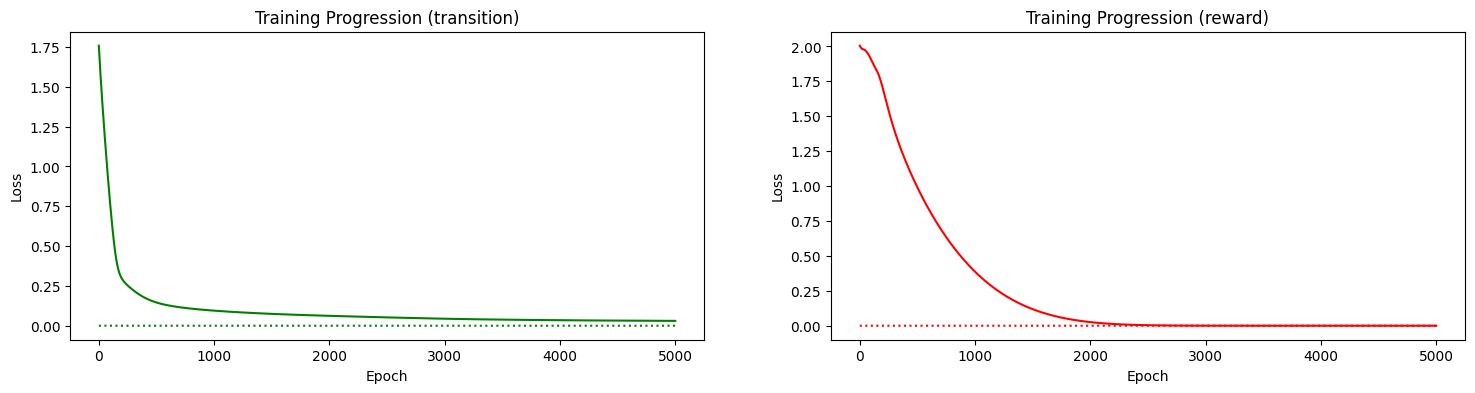

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

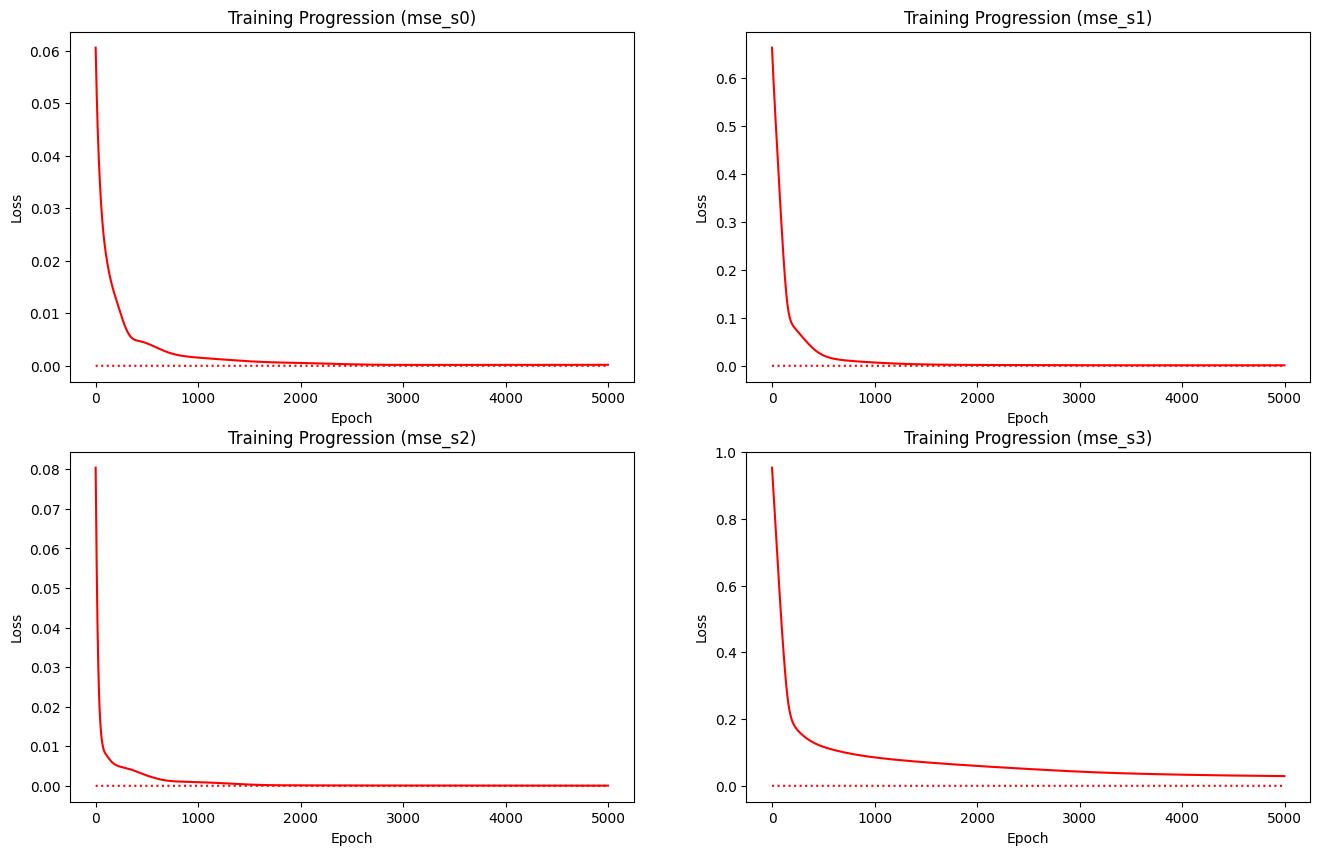

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

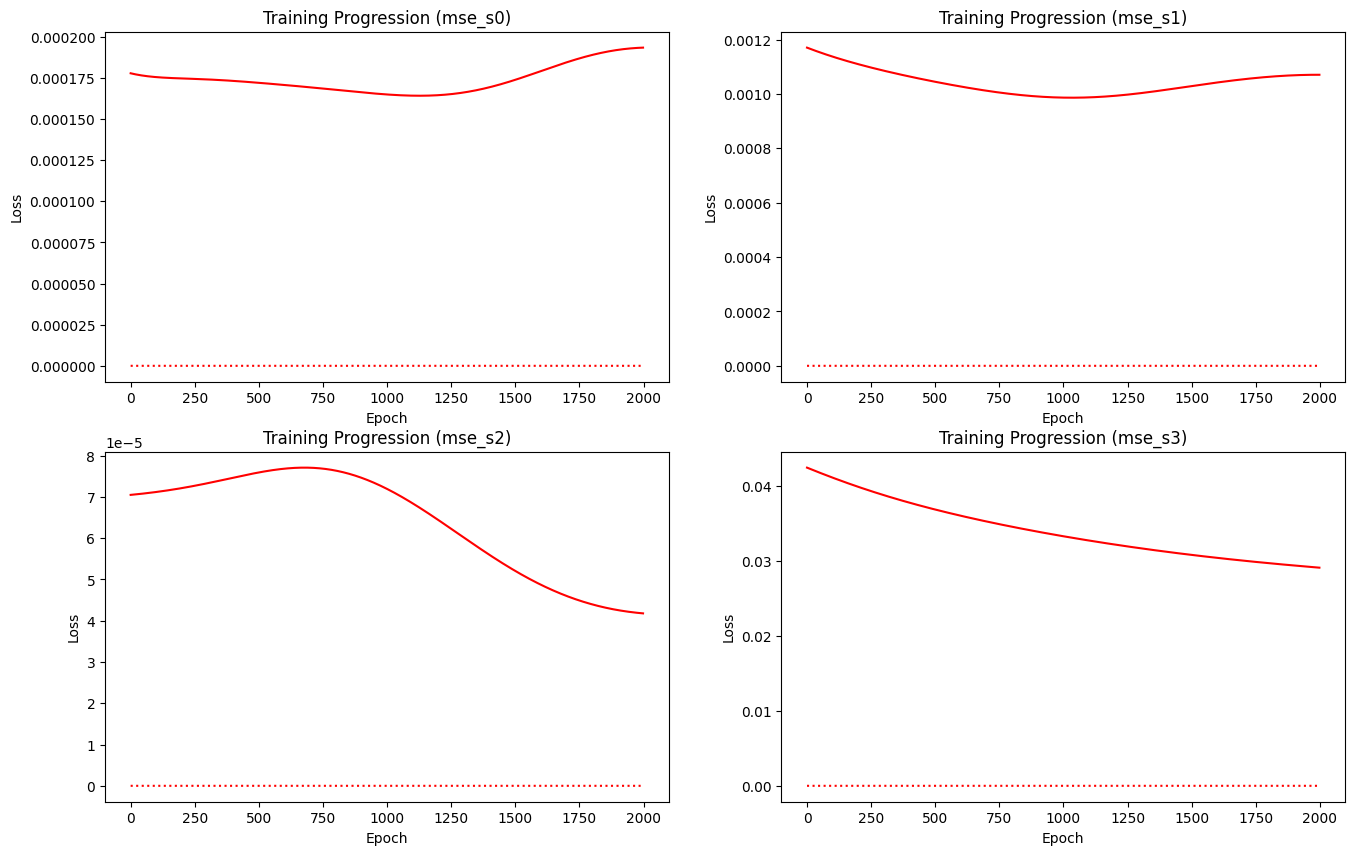

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data[train_data.epoch>3000].reset_index(drop=True), expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [7]:
data.evaluate_model(model, path='../testing_data.csv')
results = data.get_evaluation_metrics(p=False)
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
0,0,0,"(0.5280280669895349, 0.1691488904272192)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.285, 0.013, 1.258)",0.0,1.0,"(-0.025, -0.525, 0.038, 2.534)",...,0.008,0.014,0.005,0.649,0.0,0.554382,0.529499,0.513189,0.490203,0.676
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)",...,0.003,0.045,0.005,0.186,0.0,0.549102,0.537119,0.513189,0.450586,0.239
2,2,0,"(0.5280280669895349, 0.1691488904272192)","(-0.025, -0.525, 0.038, 2.534)",1,1.0,"(-0.035, -0.288, 0.088, 1.326)",0.0,1.0,"(-0.041, -0.532, 0.115, 2.694)",...,0.004,0.006,0.006,0.793,0.0,0.550158,0.527532,0.515588,0.502524,0.809
3,3,0,"(0.5280280669895349, 0.1691488904272192)","(-0.035, -0.288, 0.088, 1.326)",0,1.0,"(-0.041, -0.532, 0.115, 2.694)",1.0,1.0,"(-0.052, -0.3, 0.169, 1.601)",...,0.001,0.049,0.004,0.148,0.0,0.546990,0.538102,0.510791,0.447335,0.202
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,0.000,0.018,0.007,0.817,0.0,0.545935,0.530482,0.517986,0.504578,0.842


In [8]:
results[['rse_s0','rse_s1','rse_s2','rse_s3','rse_r','rse_s0_normalized','rse_s1_normalized','rse_s2_normalized','rse_s3_normalized', 'rse']].describe()

,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.0,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.006984,0.015782,0.003171,0.122515,0.0,0.553310,0.529937,0.508804,0.445154,0.148453
std,0.009255,0.021822,0.004004,0.152185,0.0,0.009773,0.005364,0.009602,0.013022,0.158932
min,0.000000,0.000000,0.000000,0.000000,0.0,0.545935,0.526057,0.501199,0.434671,0.006000
25%,0.002000,0.004000,0.001000,0.038000,0.0,0.548046,0.527040,0.503597,0.437922,0.062000
50%,0.004000,0.009000,0.002000,0.079000,0.0,0.550158,0.528269,0.505995,0.441431,0.103000
75%,0.008000,0.018000,0.004000,0.148000,0.0,0.554382,0.530482,0.510791,0.447335,0.177000
max,0.073000,0.421000,0.042000,1.939000,0.0,0.623020,0.629548,0.601918,0.600582,2.038000


In [10]:
import numpy as np 
n = 10

worst = results.loc[results.rank(ascending=False)['rse']<=n].episode
df = results[results['episode'].isin(worst)].reset_index(drop=True)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/pyt

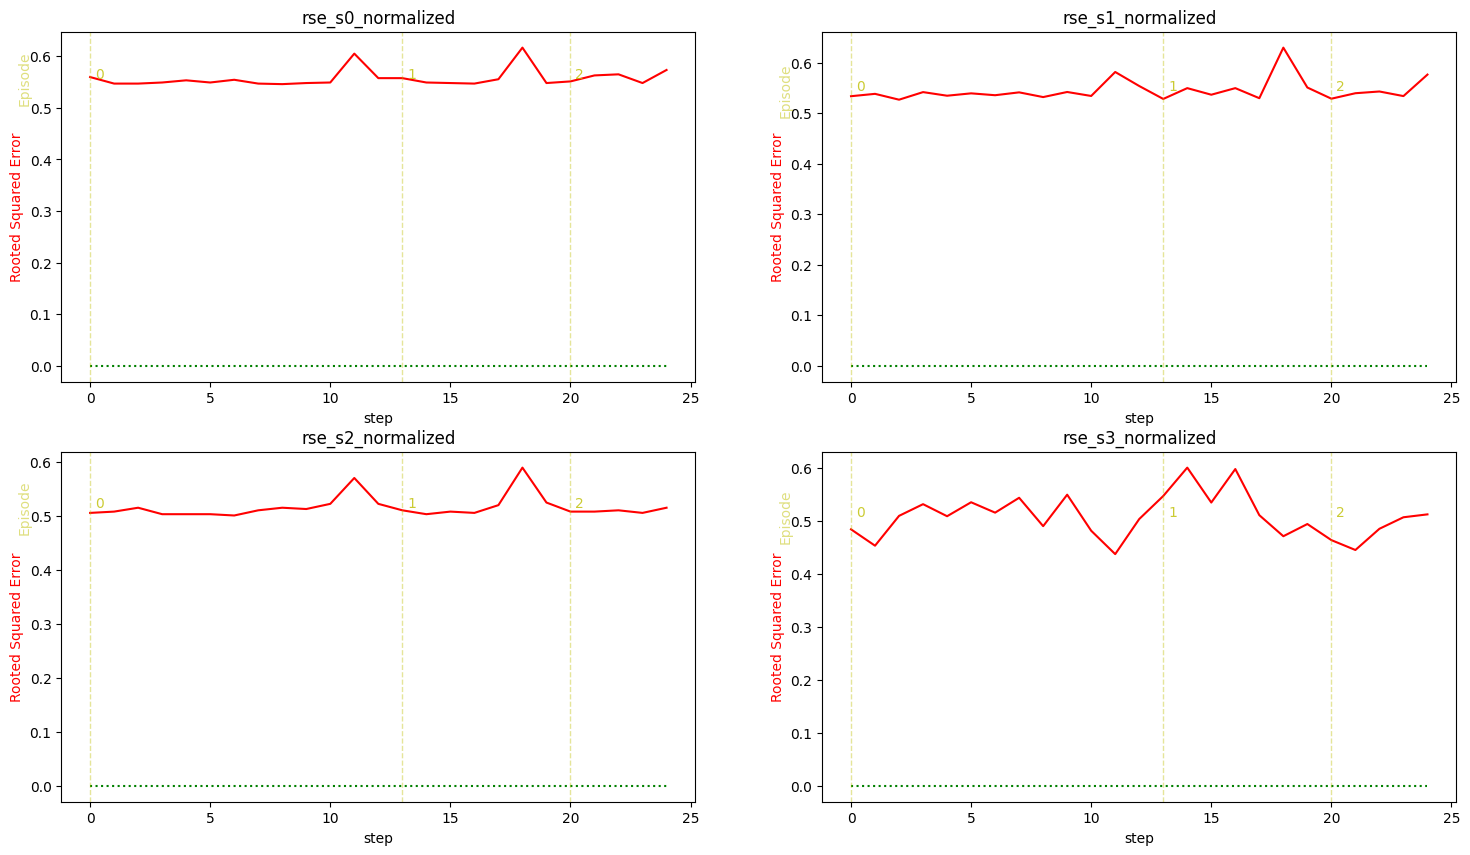

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], df, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], df, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], df, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], df, 'rse_s3_normalized')

plt.show()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


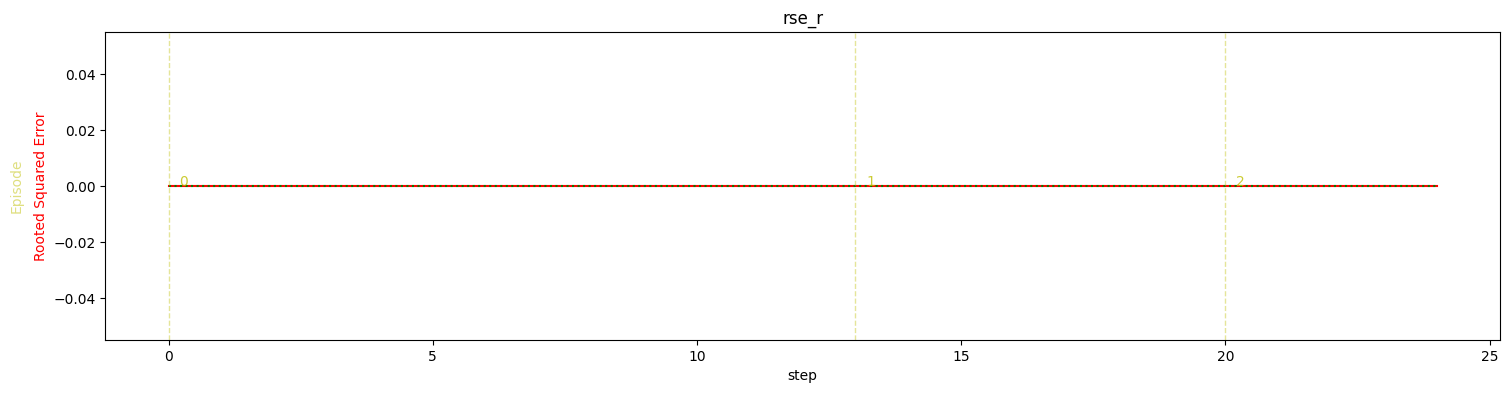

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, df, 'rse_r')
plt.show()

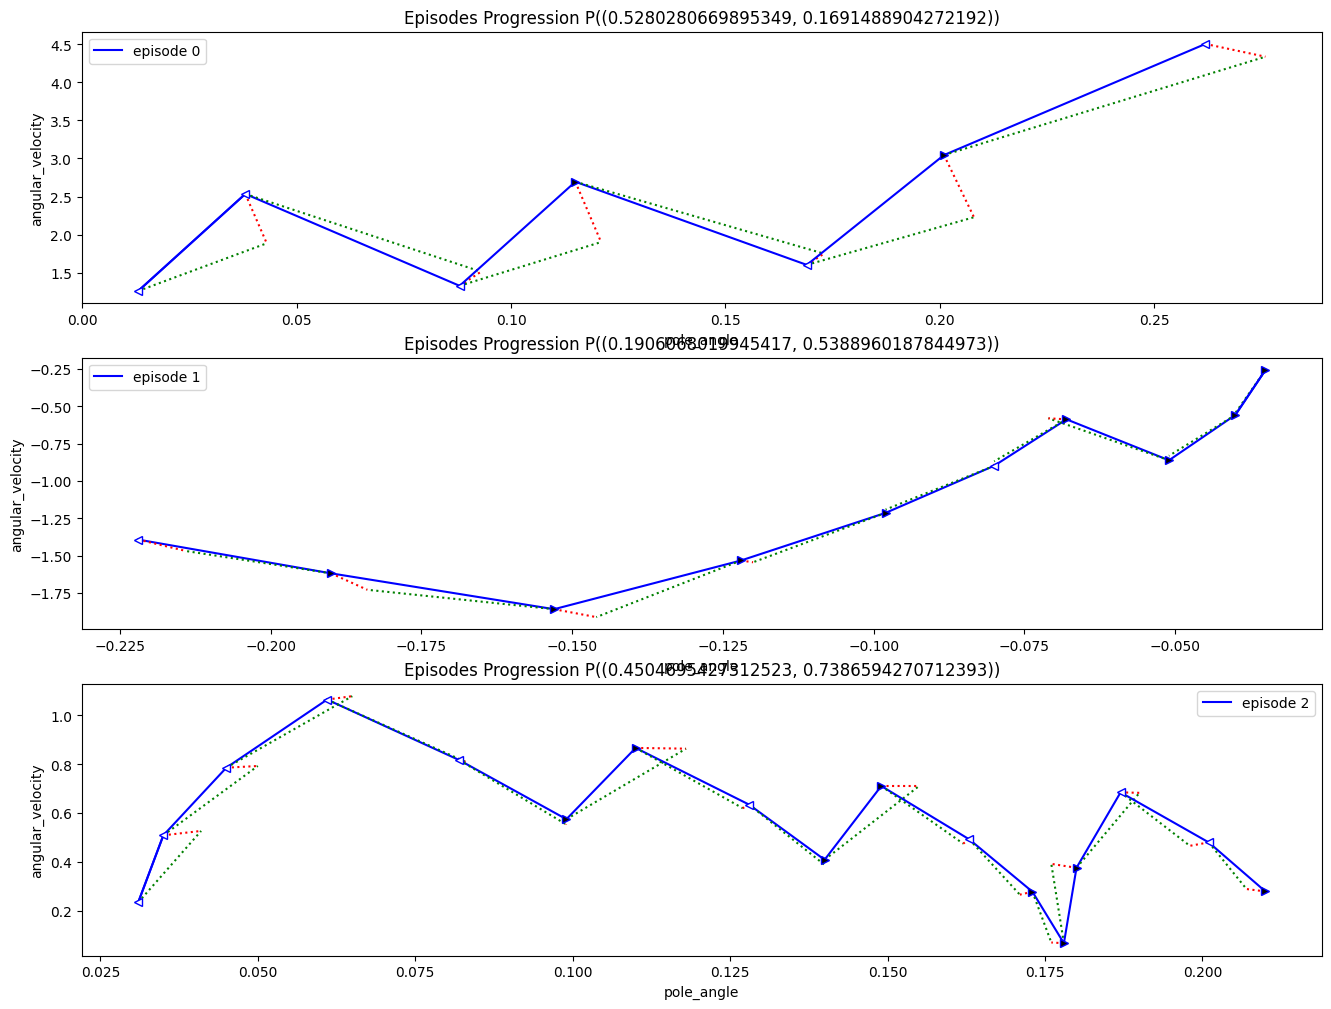

In [13]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()